In [39]:
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np


In [40]:
# 加载数据
file_path = r"D:\红茶数据2024.0423\300\dataAfterMSC\FAA.mat"
data = sio.loadmat(file_path)
X = data['X']  # shape: (samples, features)
Y = data['Y']  # shape: (samples, 1)

# 转为float32
X = X.astype(np.float32)
Y = Y.astype(np.float32)

# 划分训练集和测试集
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42) #

# 转为Tensor
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)
X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)


In [41]:
class BasicBlock(nn.Module):
    def __init__(self, in_features, out_features):
        super(BasicBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.BatchNorm1d(out_features),
            nn.LeakyReLU(0.1)
        )

    def forward(self, x):
        return self.block(x)

class DarkNetRegressor(nn.Module):
    def __init__(self, input_dim):
        super(DarkNetRegressor, self).__init__()
        self.model = nn.Sequential(
            BasicBlock(input_dim, 512),
            BasicBlock(512, 256),
            BasicBlock(256, 128),
            BasicBlock(128, 64),
            nn.Linear(64, 1)  # 输出一个回归值
        )

    def forward(self, x):
        return self.model(x)


In [42]:
# 初始化模型
model = DarkNetRegressor(input_dim=X.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练模型
epochs = 500
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, Y_train)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [20/500], Loss: 6.6287
Epoch [40/500], Loss: 4.0518
Epoch [60/500], Loss: 2.3166
Epoch [80/500], Loss: 1.1603
Epoch [100/500], Loss: 0.4542
Epoch [120/500], Loss: 0.1501
Epoch [140/500], Loss: 0.0505
Epoch [160/500], Loss: 0.0229
Epoch [180/500], Loss: 0.0230
Epoch [200/500], Loss: 0.0103
Epoch [220/500], Loss: 0.0076
Epoch [240/500], Loss: 0.0077
Epoch [260/500], Loss: 0.0047
Epoch [280/500], Loss: 0.0139
Epoch [300/500], Loss: 0.0065
Epoch [320/500], Loss: 0.0039
Epoch [340/500], Loss: 0.0031
Epoch [360/500], Loss: 0.0031
Epoch [380/500], Loss: 0.0026
Epoch [400/500], Loss: 0.0032
Epoch [420/500], Loss: 0.0025
Epoch [440/500], Loss: 0.0034
Epoch [460/500], Loss: 0.0011
Epoch [480/500], Loss: 0.0010
Epoch [500/500], Loss: 0.0008


Rc = 0.9443, RMSEC = 0.1501
Rp = -0.0220, RMSEP = 0.5731


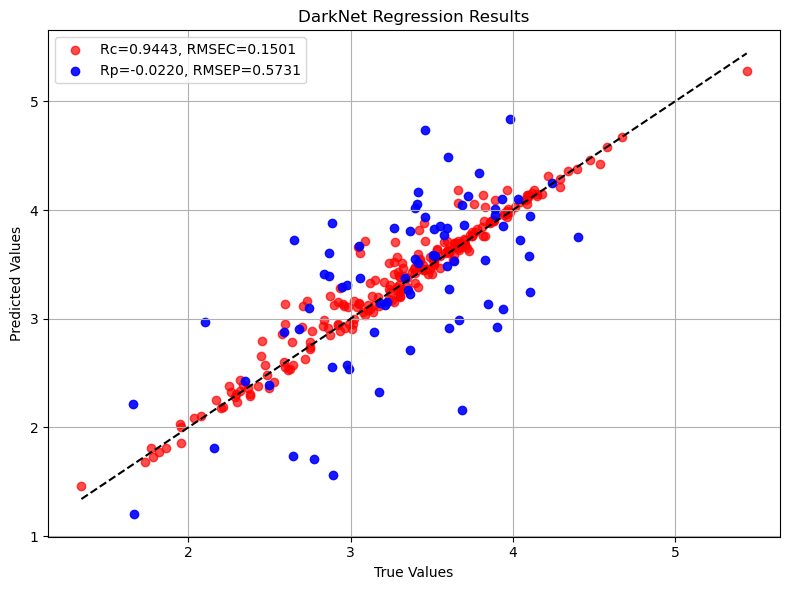

In [48]:
# 预测训练集和测试集
model.eval()
with torch.no_grad():
    Y_train_pred = model(X_train).numpy()
    Y_test_pred = model(X_test).numpy()

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

Rc = r2_score(Y_train.numpy(), Y_train_pred)
Rp = r2_score(Y_test.numpy(), Y_test_pred)
RMSEC = rmse(Y_train.numpy(), Y_train_pred)
RMSEP = rmse(Y_test.numpy(), Y_test_pred)

print(f"Rc = {Rc:.4f}, RMSEC = {RMSEC:.4f}")
print(f"Rp = {Rp:.4f}, RMSEP = {RMSEP:.4f}")

# ========== 6. 绘图 ==========
plt.figure(figsize=(8, 6))

plt.scatter(Y_train.numpy(), Y_train_pred, color='red', label=f"Rc={Rc:.4f}, RMSEC={RMSEC:.4f}", alpha=0.7)
plt.scatter(Y_test.numpy(), Y_test_pred, color='blue', label=f"Rp={Rp:.4f}, RMSEP={RMSEP:.4f}", alpha=0.9)

plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], '--k')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("DarkNet Regression Results")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()